 MEMPROSES GAMBAR 1: gerbang.jpg (930x620 piksel)


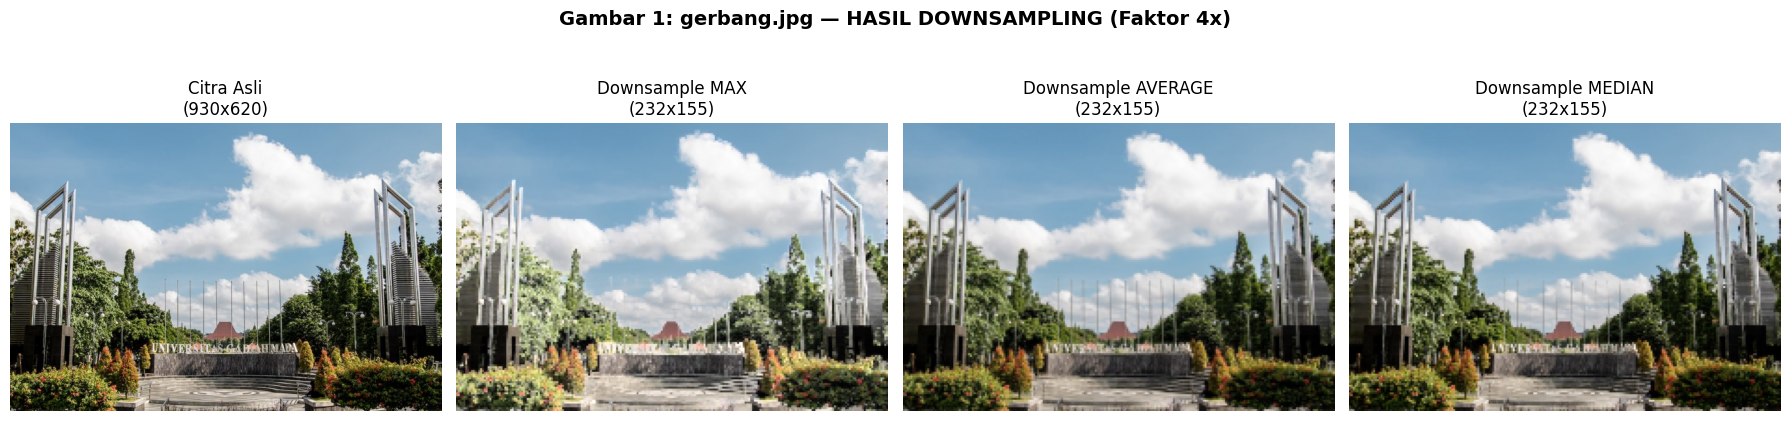

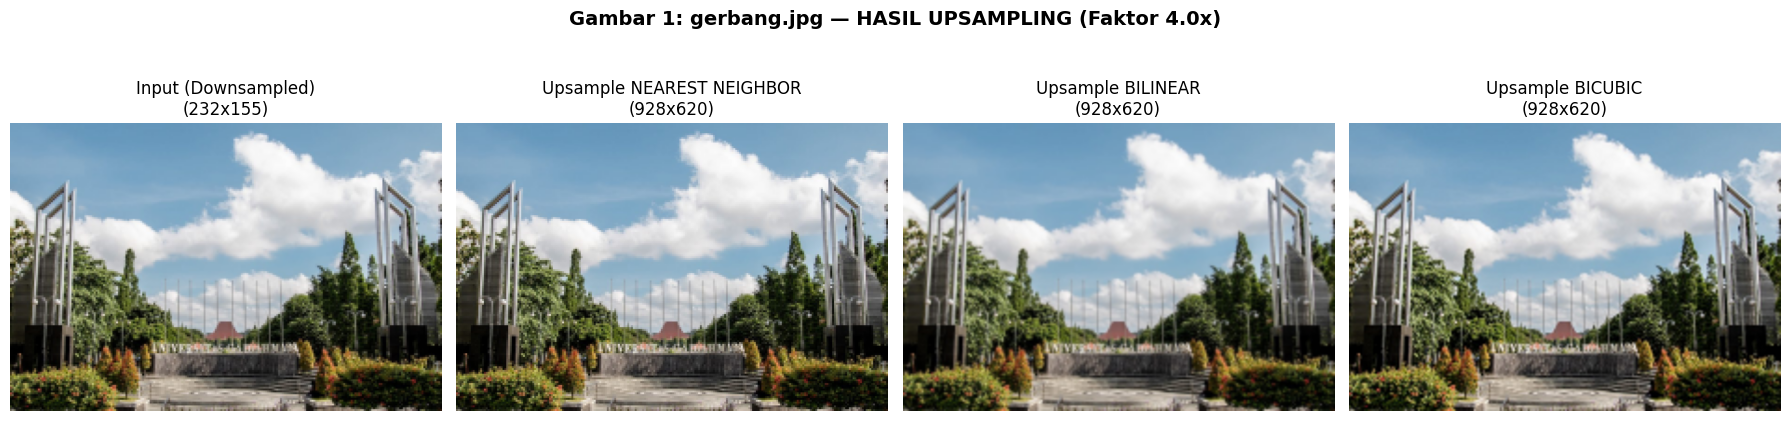

 MEMPROSES GAMBAR 2: langit.jpg (250x187 piksel)


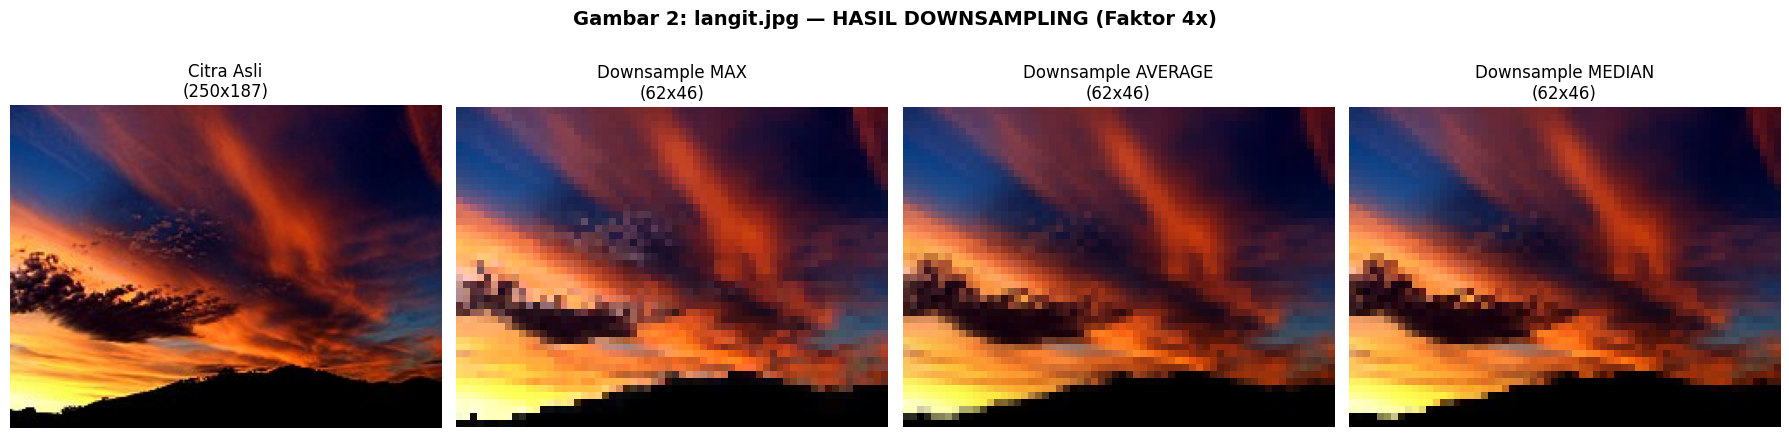

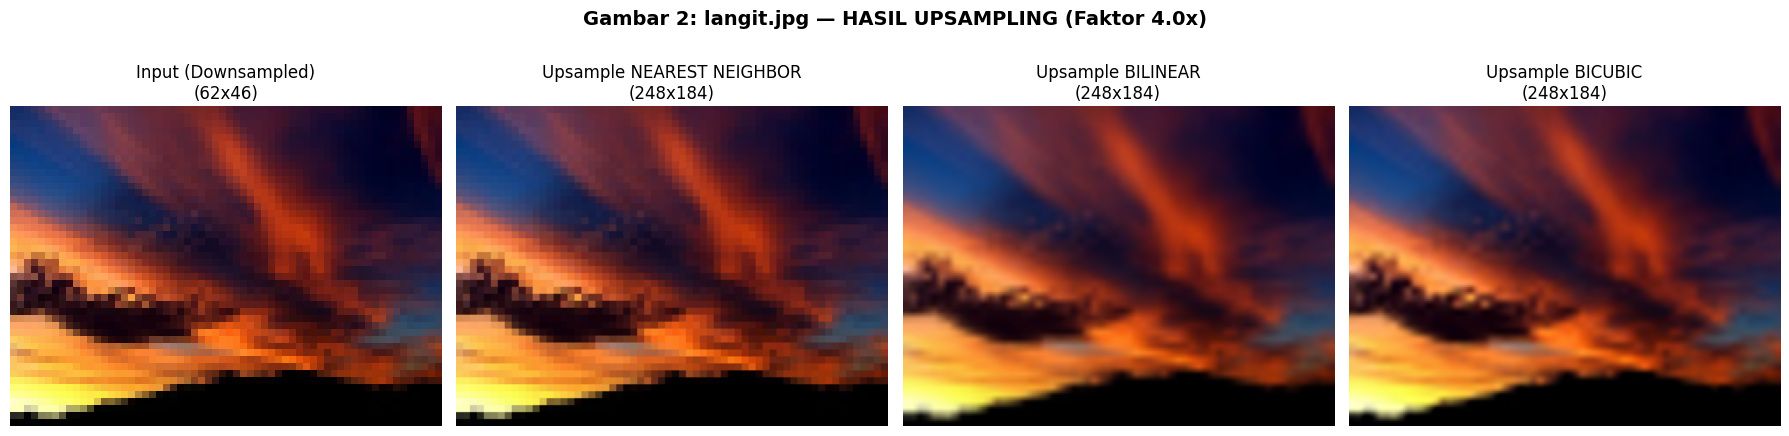

 MEMPROSES GAMBAR 3: lineart.jpg (564x669 piksel)


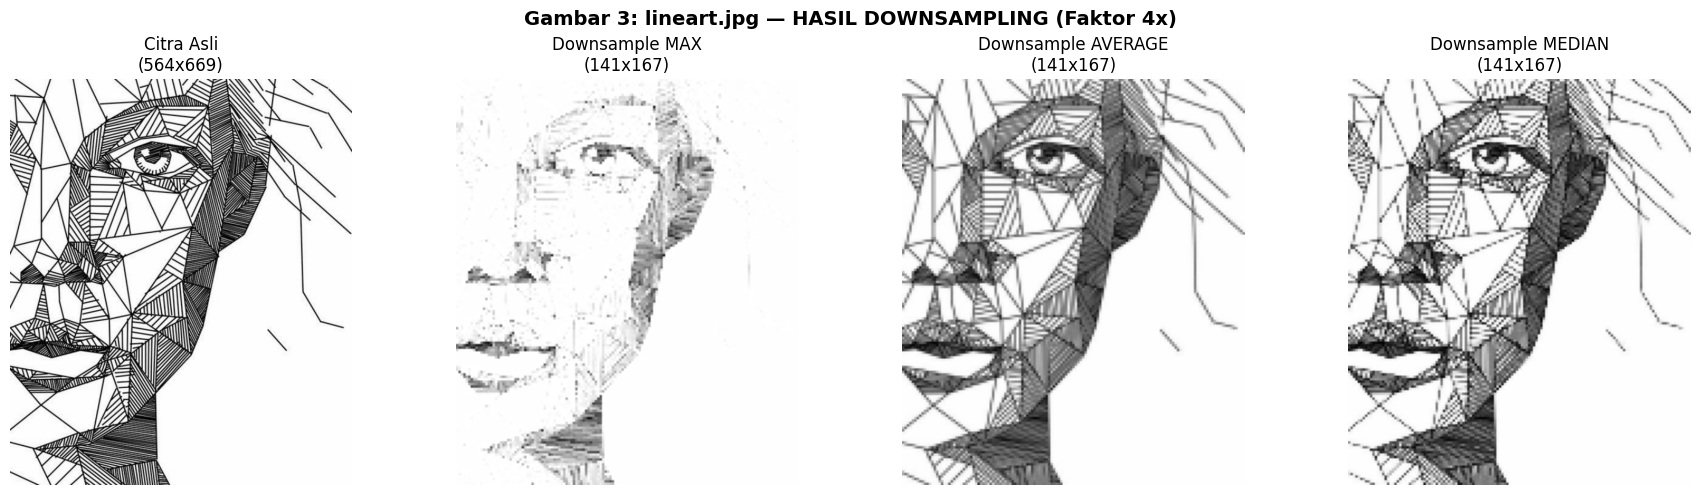

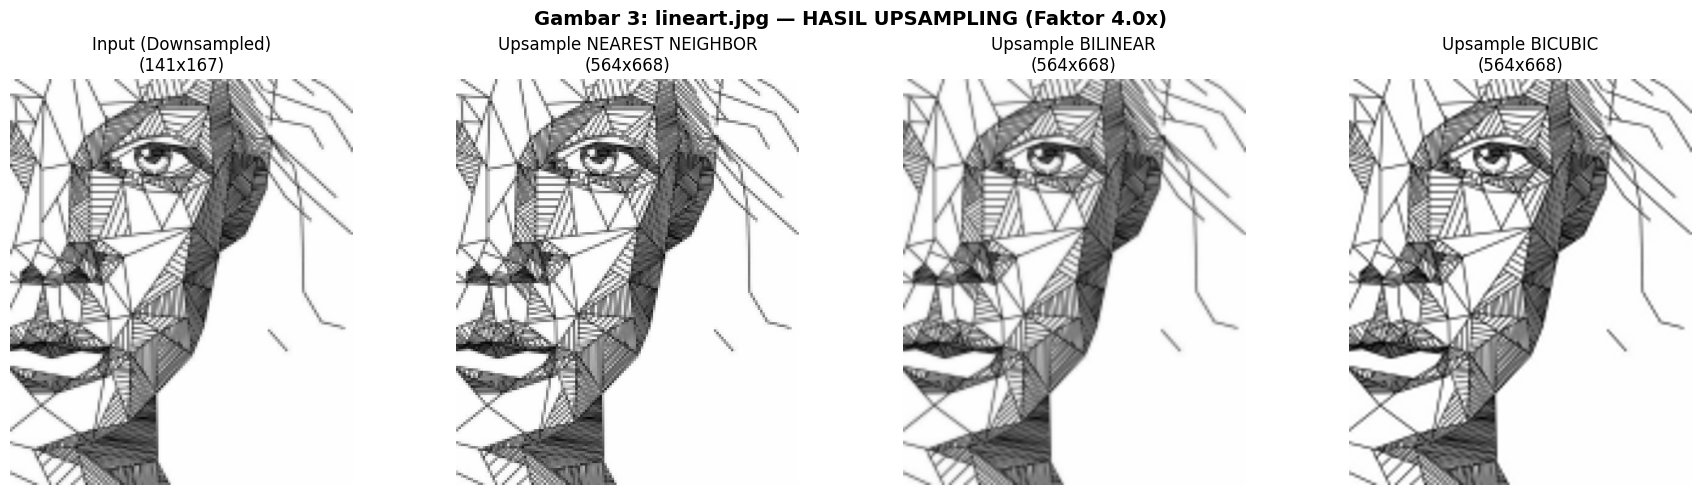

In [7]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def downsample_manual(img, factor=2, mode='average'):
    """
    Mengurangi ukuran citra menggunakan blok k x k.
    mode: 'max', 'average', atau 'median'
    """
    h, w = img.shape[:2]
    new_h = h // factor
    new_w = w // factor

    cropped = img[:new_h * factor, :new_w * factor]

    if img.ndim == 2: # kalau citranya grayscale
        output = np.zeros((new_h, new_w), dtype=np.float64)
        for i in range(new_h):
            for j in range(new_w):
                block = cropped[i*factor:(i+1)*factor, j*factor:(j+1)*factor]
                if mode == 'max':
                    output[i, j] = np.max(block)
                elif mode == 'average':
                    output[i, j] = np.mean(block)
                elif mode == 'median':
                    output[i, j] = np.median(block)
    else: # kalau citranya rgb
        output = np.zeros((new_h, new_w, img.shape[2]), dtype=np.float64)
        for c in range(img.shape[2]):
            for i in range(new_h):
                for j in range(new_w):
                    block = cropped[i*factor:(i+1)*factor, j*factor:(j+1)*factor, c]
                    if mode == 'max':
                        output[i, j, c] = np.max(block)
                    elif mode == 'average':
                        output[i, j, c] = np.mean(block)
                    elif mode == 'median':
                        output[i, j, c] = np.median(block)

    return np.clip(output, 0, 255).astype(np.uint8)

def upsample_nn(img, scale_factor=2.0):
    """Upsampling metode Nearest Neighbor"""
    h, w = img.shape[:2]
    new_h, new_w = int(h * scale_factor), int(w * scale_factor)

    grid_y = np.clip(np.floor(np.arange(new_h) / scale_factor).astype(int), 0, h - 1)
    grid_x = np.clip(np.floor(np.arange(new_w) / scale_factor).astype(int), 0, w - 1)

    if img.ndim == 2:
        return img[np.ix_(grid_y, grid_x)]
    else:
        return img[np.ix_(grid_y, grid_x, np.arange(img.shape[2]))]

def upsample_bilinear(img, scale_factor=2.0):
    """Upsampling metode Bilinear Interpolation"""
    h, w = img.shape[:2]
    new_h, new_w = int(h * scale_factor), int(w * scale_factor)

    y_indices = np.clip((np.arange(new_h) + 0.5) / scale_factor - 0.5, 0, h - 1)
    x_indices = np.clip((np.arange(new_w) + 0.5) / scale_factor - 0.5, 0, w - 1)

    y1 = np.floor(y_indices).astype(int)
    y2 = np.minimum(y1 + 1, h - 1)
    dy = (y_indices - y1)[:, np.newaxis]

    x1 = np.floor(x_indices).astype(int)
    x2 = np.minimum(x1 + 1, w - 1)
    dx = (x_indices - x1)[np.newaxis, :]

    if img.ndim == 2:
        I11 = img[np.ix_(y1, x1)]
        I12 = img[np.ix_(y1, x2)]
        I21 = img[np.ix_(y2, x1)]
        I22 = img[np.ix_(y2, x2)]

        top = (1 - dx) * I11 + dx * I12
        bottom = (1 - dx) * I21 + dx * I22
        out = (1 - dy) * top + dy * bottom
    else:
        out = np.zeros((new_h, new_w, img.shape[2]), dtype=np.float64)
        for c in range(img.shape[2]):
            I11 = img[np.ix_(y1, x1, [c])][:, :, 0]
            I12 = img[np.ix_(y1, x2, [c])][:, :, 0]
            I21 = img[np.ix_(y2, x1, [c])][:, :, 0]
            I22 = img[np.ix_(y2, x2, [c])][:, :, 0]

            top = (1 - dx) * I11 + dx * I12
            bottom = (1 - dx) * I21 + dx * I22
            out[:, :, c] = (1 - dy) * top + dy * bottom

    return np.clip(out, 0, 255).astype(np.uint8)

def cubic_kernel(x, a=-0.5):
    """Fungsi pembobotan kubik (Kernel Catmull-Rom)"""
    abs_x = np.abs(x)
    abs_x2 = abs_x ** 2
    abs_x3 = abs_x ** 3

    w = np.zeros_like(x, dtype=np.float64)
    c1 = (abs_x <= 1)
    c2 = (abs_x > 1) & (abs_x < 2)

    w[c1] = (a + 2) * abs_x3[c1] - (a + 3) * abs_x2[c1] + 1
    w[c2] = a * abs_x3[c2] - 5 * a * abs_x2[c2] + 8 * a * abs_x[c2] - 4 * a
    return w

def upsample_bicubic(img, scale_factor=2.0):
    """Upsampling metode Bicubic Interpolation"""
    h, w = img.shape[:2]
    new_h, new_w = int(h * scale_factor), int(w * scale_factor)

    y_indices = (np.arange(new_h) + 0.5) / scale_factor - 0.5
    x_indices = (np.arange(new_w) + 0.5) / scale_factor - 0.5

    channels = 1 if img.ndim == 2 else img.shape[2]
    img_exp = img[:, :, np.newaxis] if img.ndim == 2 else img
    out = np.zeros((new_h, new_w, channels), dtype=np.float64)

    for i in range(new_h):
        y = y_indices[i]
        y0 = int(np.floor(y))
        vy = y - y0
        wy = cubic_kernel(vy - np.arange(-1, 3))
        y_coords = np.clip(y0 + np.arange(-1, 3), 0, h - 1)

        for j in range(new_w):
            x = x_indices[j]
            x0 = int(np.floor(x))
            vx = x - x0
            wx = cubic_kernel(vx - np.arange(-1, 3))
            x_coords = np.clip(x0 + np.arange(-1, 3), 0, w - 1)

            block = img_exp[np.ix_(y_coords, x_coords, np.arange(channels))]
            weights = wy[:, np.newaxis] * wx[np.newaxis, :]

            for c in range(channels):
                out[i, j, c] = np.sum(block[:, :, c] * weights)

    out = np.clip(out, 0, 255).astype(np.uint8)
    return out[:, :, 0] if img.ndim == 2 else out

image_paths = [
    'gerbang.jpg',
    'langit.jpg',
    'lineart.jpg'
]

DOWN_FACTOR = 4
UP_SCALE = 4.0

for idx, path in enumerate(image_paths):
    img_bgr = cv2.imread(path)

    if img_bgr is None:
        print(f"⚠️ PERINGATAN: Berkas '{path}' tidak ditemukan di folder Colab. Lewati gambar ini.")
        continue

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    print(f" MEMPROSES GAMBAR {idx+1}: {path} ({img_rgb.shape[1]}x{img_rgb.shape[0]} piksel)")

    ds_max = downsample_manual(img_rgb, factor=DOWN_FACTOR, mode='max')
    ds_avg = downsample_manual(img_rgb, factor=DOWN_FACTOR, mode='average')
    ds_med = downsample_manual(img_rgb, factor=DOWN_FACTOR, mode='median')

    us_nn = upsample_nn(ds_avg, scale_factor=UP_SCALE)
    us_bilinear = upsample_bilinear(ds_avg, scale_factor=UP_SCALE)
    us_bicubic = upsample_bicubic(ds_avg, scale_factor=UP_SCALE)

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    fig.suptitle(f"Gambar {idx+1}: {path} — HASIL DOWNSAMPLING (Faktor {DOWN_FACTOR}x)", fontsize=14, fontweight='bold')

    axes[0].imshow(img_rgb)
    axes[0].set_title(f"Citra Asli\n({img_rgb.shape[1]}x{img_rgb.shape[0]})")

    axes[1].imshow(ds_max)
    axes[1].set_title(f"Downsample MAX\n({ds_max.shape[1]}x{ds_max.shape[0]})")

    axes[2].imshow(ds_avg)
    axes[2].set_title(f"Downsample AVERAGE\n({ds_avg.shape[1]}x{ds_avg.shape[0]})")

    axes[3].imshow(ds_med)
    axes[3].set_title(f"Downsample MEDIAN\n({ds_med.shape[1]}x{ds_med.shape[0]})")

    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    fig.suptitle(f"Gambar {idx+1}: {path} — HASIL UPSAMPLING (Faktor {UP_SCALE}x)", fontsize=14, fontweight='bold')

    axes[0].imshow(ds_avg)
    axes[0].set_title(f"Input (Downsampled)\n({ds_avg.shape[1]}x{ds_avg.shape[0]})")

    axes[1].imshow(us_nn)
    axes[1].set_title(f"Upsample NEAREST NEIGHBOR\n({us_nn.shape[1]}x{us_nn.shape[0]})")

    axes[2].imshow(us_bilinear)
    axes[2].set_title(f"Upsample BILINEAR\n({us_bilinear.shape[1]}x{us_bilinear.shape[0]})")

    axes[3].imshow(us_bicubic)
    axes[3].set_title(f"Upsample BICUBIC\n({us_bicubic.shape[1]}x{us_bicubic.shape[0]})")

    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# LAPORAN ANALISIS PRAKTIKUM PENGOLAHAN CITRA DIGITAL
**TOPIK: AKUISISI CITRA – DOWNSAMPLING DAN UPSAMPLING**

**Identitas Tugas**
* **Nama**: Farhan Rizky Alkarim
* **NIM**: 25/568476/PA/23997
* **Mata Kuliah**: Pengolahan Citra Digital
* **Platform Pengujian**: Google Colab (Python / NumPy Base)

---

## 1. Pendahuluan dan Latar Belakang

Akuisisi citra merupakan tahapan paling awal dalam sistem pengolahan citra digital yang melibatkan proses transformasi sinyal kontinu dari dunia nyata menjadi matriks diskrit yang dapat diproses oleh komputer. Dalam praktikum ini, evaluasi difokuskan pada dua operasi spasial utama: **Downsampling** (penurunan resolusi spasial) dan **Upsampling** (merekonstruksi kembali citra ke resolusi yang lebih tinggi).

Proses reduksi dan rekonstruksi ini dilakukan secara manual menggunakan manipulasi matriks berbasis NumPy tanpa memanfaatkan pustaka pengolah citra tingkat tinggi seperti OpenCV (`cv2.resize`). Untuk menguji ketahanan dan dampak dari masing-masing algoritma, pengujian dilakukan terhadap tiga jenis citra input yang memiliki karakteristik frekuensi spasial berbeda:
1. **Citra High Frequency (Detail/Tekstur Tajam):** Citra yang kaya akan perubahan garis ketajaman, seperti arsitektur bangunan, serat bulu hewan, atau pola berulang.
2. **Citra Low Frequency (Gradasi Mulus):** Citra dengan transisi warna yang relatif halus dan perlahan, seperti lanskap pemandangan alam, kulit, atau warna langit.
3. **Citra Biner / Line Art (Teks dan Logo):** Citra dengan kontras tinggi yang dominan memiliki batas warna tegas antara latar depan (*foreground*) dan latar belakang (*background*).

---

## 2. Analisis Metode Downsampling

Proses *downsampling* dilakukan dengan membagi citra input menjadi blok-blok kecil berukuran $4 \times 4$ piksel (faktor reduksi 4x), kemudian mengekstraksi satu nilai tunggal dari setiap blok untuk merepresentasikan piksel baru pada citra output.

### 2.1. Max Downsampling
* **Mekanisme Kerja:** Mengambil nilai intensitas kecerahan tertinggi ($\max$) dari seluruh piksel yang berada di dalam satu blok $4 \times 4$.
* **Hasil Pengamatan Visual:** Metode ini cenderung mempertahankan dan mempertegas fitur-fitur yang terang (*bright features*) serta batas tepi (*edges*). Pada citra biner atau teks, *Max Downsampling* membuat ketebalan garis teks bertambah secara visual.
* **Kelemahan:** Pada citra dengan gradasi halus (Low Frequency), terjadi distorsi kecerahan yang signifikan. Citra mengalami peningkatan kecerahan secara tidak seimbang (*overexposure*), serta kehilangan informasi pada area-area gelap/bayangan.

### 2.2. Average Downsampling
* **Mekanisme Kerja:** Menghitung nilai rata-rata aritmetika ($\text{mean}$) dari seluruh intensitas piksel di dalam blok $4 \times 4$.
* **Hasil Pengamatan Visual:** Menghasilkan citra hasil reduksi yang paling proporsional secara keseluruhan. Distribusi intensitas dan rata-rata kecerahan warna citra asli dapat dipertahankan dengan sangat baik.
* **Kelemahan:** Mengalami efek pengaburan halus (*blurring*) pada area-area yang memiliki tekstur rapat atau detail tinggi (High Frequency), karena nilai piksel ekstrim diratakan.

### 2.3. Median Downsampling
* **Mekanisme Kerja:** Mengurutkan seluruh nilai piksel di dalam blok $4 \times 4$ secara mendatar, kemudian mengambil nilai intensitas yang berada tepat di tengah-tengah (elemen *median*).
* **Hasil Pengamatan Visual:** Karakteristik visual yang dihasilkan mirip dengan *Average Downsampling*, namun dengan kemampuan mempertahankan ketajaman batas tepi (*edge sharpness*) yang sedikit lebih baik.
* **Keunggulan Khusus:** Sangat efisien dalam mengeliminasi bintik-bintik derau acak (*salt-and-pepper noise*), karena nilai piksel ekstrim yang diakibatkan oleh *noise* secara otomatis terabaikan saat pengambilan nilai median.

---

## 3. Analisis Metode Upsampling

Proses *upsampling* merekonstruksi citra hasil reduksi (*downsampled image*) agar kembali ke dimensi ukuran semula (faktor perbesaran 4.0x) dengan memperkirakan nilai piksel baru pada posisi-posisi koordinat yang kosong.

### 3.1. Nearest Neighbor Interpolation
* **Mekanisme Kerja:** Mengisi nilai piksel pada posisi koordinat baru dengan menyalin nilai intensitas dari piksel terdekat pada citra asal tanpa pembobotan matematika.
* **Hasil Pengamatan Visual:** Menghasilkan efek berpetak-petak atau gerigi yang sangat tajam (*pixelated/staircase effect*), terutama pada batas garis diagonal dan kurva melengkung.
* **Analisis Kinerja:** Memiliki kompleksitas komputasi yang paling rendah dan proses eksekusi paling cepat. Meskipun kurang memuaskan untuk fotografi alami, metode ini sangat cocok untuk mempertahankan ketajaman grafik piksel (*pixel art*) atau dokumen teks tanpa menimbulkan area buram di sekitar huruf.

### 3.2. Bilinear Interpolation
* **Mekanisme Kerja:** Menghitung nilai piksel baru berdasarkan rata-rata terbobot dari 4 piksel tetangga terdekat ($2 \times 2$) yang mengelilingi posisi target, menggunakan interpolasi linier pada sumbu horizontal dan vertikal.
* **Hasil Pengamatan Visual:** Mengeliminasi efek gerigi berkotak-kotak secara signifikan dan menghasilkan transisi gradasi warna yang jauh lebih mulus jika dibandingkan dengan *Nearest Neighbor*.
* **Analisis Kinerja:** Memberikan keseimbangan yang baik antara kualitas visual dan beban komputasi. Namun, pada batas tepi yang tajam, hasil rekonstruksi cenderung terlihat sedikit buram (*fuzzy/soft edges*).

### 3.3. Bicubic Interpolation
* **Mekanisme Kerja:** Memperhitungkan matriks $4 \times 4$ (total 16 piksel tetangga) mengelilingi koordinat target dengan menerapkan fungsi kurva pembobotan kubik (Kernel Catmull-Rom).
* **Hasil Pengamatan Visual:** Menghasilkan kualitas rekonstruksi visual tertinggi dari seluruh metode yang diuji. Garis tepi objek dipertahankan secara tajam (*sharp edges*) dengan gradasi antar-piksel yang sangat natural.
* **Analisis Kinerja:** Metode ini meminimalkan efek artefak visual secara maksimal, namun membutuhkan daya komputasi dan waktu pemrosesan paling tinggi karena kompleksitas perhitungan fungsi kubik pada 16 tetangga piksel.

---

## 4. Evaluasi Komparatif Berdasarkan Karakteristik Citra Input

### 4.1. Uji Coba Citra High Frequency (Detail & Tekstur)
* Pada saat dilakukan *downsampling*, metode *Average* dan *Median* menghasilkan citra yang paling mendekati penampilan citra asli, sedangkan *Max* cenderung menghilangkan tekstur gelap.
* Saat proses *upsampling*, teknik *Bicubic Interpolation* terbukti paling unggul dalam merekonstruksi kembali tekstur-tekstur rapat tanpa memunculkan efek garis patah-patah yang mengganggu.

### 4.2. Uji Coba Citra Low Frequency (Gradasi Mulus)
* *Average Downsampling* mempertahankan kehalusan transisi warna pada area langit/pemandangan secara sempurna. Sebaliknya, *Max Downsampling* merusak gradasi alami dengan memunculkan kontur buatan yang terlalu terang.
* Pada rekonstruksi *upsampling*, *Bilinear* dan *Bicubic* mampu menghasilkan permukaan yang mulus tanpa efek *banding*. *Nearest Neighbor* gagal menghasilkan visualisasi yang baik karena memecah gradasi mulus menjadi kotak-kotak warna terpisah.

### 4.3. Uji Coba Citra Biner / Line Art (Teks & Logo)
* *Max Downsampling* mempertegas keterbacaan garis teks yang tipis, sementara *Average Downsampling* menyebabkan area tepi teks menjadi agak abu-abu/buram.
* Untuk *upsampling* citra teks, *Nearest Neighbor* mempertahankan ketajaman garis batas latar hitam-putih secara tegas, sedangkan *Bilinear* dan *Bicubic* menghasilkan efek bayangan buram (*halo effect*) di sekeliling karakter huruf.

---

## 5. Kesimpulan

Berdasarkan pengujian dan analisis yang telah dilakukan, dapat disimpulkan beberapa poin utama:
1. Tidak ada satu metode tunggal yang sempurna untuk semua kondisi; pemilihan algoritma *sampling* harus disesuaikan dengan karakteristik frekuensi spasial citra dan tujuan akhir pengolahan.
2. Untuk proses **Downsampling**, metode *Average* merupakan pilihan terbaik secara umum untuk mempertahankan distribusi warna alami. *Max Downsampling* lebih tepat digunakan untuk aplikasi ekstraksi fitur/tepi, sedangkan *Median Downsampling* sangat efektif untuk eliminasi *noise*.
3. Untuk proses **Upsampling**, terdapat *trade-off* yang jelas antara kualitas estetika visual dan kecepatan komputasi. *Bicubic Interpolation* memberikan rekonstruksi paling natural dan tajam untuk fotografi, sementara *Nearest Neighbor* unggul dalam kecepatan pemrosesan dan efisiensi pada citra teks atau grafik biner.